# Week5 lab

In [1]:
from datetime import datetime, timedelta

import cmcrameri as cmc  # noqa: F401
import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import odc.stac
import pandas as pd
import pystac_client
import rioxarray  # noqa: F401
import xarray as xr
from odc.geo.geobox import GeoBox
from shapely.geometry import Polygon
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from skimage.filters import threshold_otsu


### Part 1: Data Aquisition + Preprocessing

Following the code in the lab, pull Sentinel 2 data over Vienna from May of 2024. Load the data into an xarray dataset and visualize the RGB image and false color composite.

In [2]:
dx = 0.0006  # 60m resolution
epsg = 4326

# Set Spatial extent
latmin, latmax = 47.86, 48.407
lonmin, lonmax = 16.32, 16.9
bounds = (lonmin, latmin, lonmax, latmax)


# Set Temporal extent
start_date = datetime(year=2024, month=5, day=1)
end_date = start_date + timedelta(days=10)

time_format = "%Y-%m-%d"
date_query = start_date.strftime(time_format) + "/" + end_date.strftime(time_format)

# Search for Sentinel-2 data
items = (
    pystac_client.Client.open("https://earth-search.aws.element84.com/v1")
    .search(
        bbox=bounds,
        collections=["sentinel-2-l2a"],
        datetime=date_query,
        limit=100,
    )
    .item_collection()
)
print(len(items), "scenes found")

10 scenes found


In [3]:
#loading data into xarray dataset
# define a geobox for my region
geobox = GeoBox.from_bbox(bounds, crs=f"epsg:{epsg}", resolution=dx)

# lazily combine items into a datacube
dc = odc.stac.load(
    items,
    bands=["scl", "red", "green", "blue", "nir"],
    chunks={"time": 5, "x": 600, "y": 600},
    geobox=geobox,
    resampling="bilinear",
)
dc

<xarray.Dataset> Size: 79MB
Dimensions:      (latitude: 913, longitude: 967, time: 10)
Coordinates:
  * latitude     (latitude) float64 7kB 48.41 48.41 48.41 ... 47.86 47.86 47.86
  * longitude    (longitude) float64 8kB 16.32 16.32 16.32 ... 16.9 16.9 16.9
  * time         (time) datetime64[ns] 80B 2024-05-01T09:57:21.858000 ... 202...
    spatial_ref  int32 4B 4326
Data variables:
    scl          (time, latitude, longitude) uint8 9MB dask.array<chunksize=(5, 600, 600), meta=np.ndarray>
    red          (time, latitude, longitude) uint16 18MB dask.array<chunksize=(5, 600, 600), meta=np.ndarray>
    green        (time, latitude, longitude) uint16 18MB dask.array<chunksize=(5, 600, 600), meta=np.ndarray>
    blue         (time, latitude, longitude) uint16 18MB dask.array<chunksize=(5, 600, 600), meta=np.ndarray>
    nir          (time, latitude, longitude) uint16 18MB dask.array<chunksize=(5, 600, 600), meta=np.ndarray>

f:\GitHub\musa-650-spring2026\.venv\Lib\site-packages\rasterio\warp.py:385: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


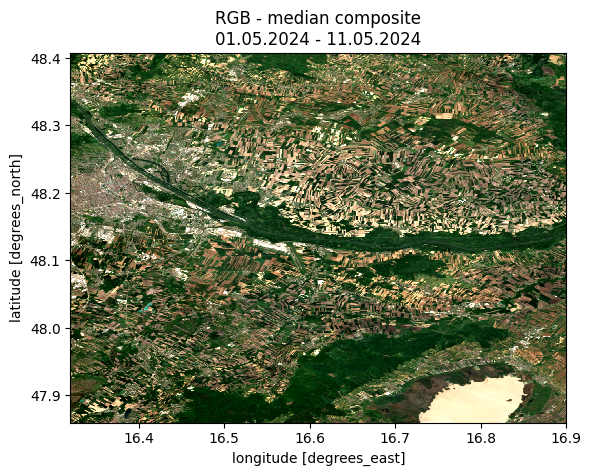

In [4]:
#visualize RGB image and false colour composite
def is_valid_pixel(data):
    return ((data > 3) & (data < 7)) | (data == 11) #vegitated, not vegitated, water, and snow

dc["valid"] = is_valid_pixel(dc.scl)

#compute masked median
rgb_median = (
    dc[["red", "green", "blue"]]
    .where(dc.valid)
    .to_dataarray(dim="band")
    .median(dim="time")
    .astype(int)
)

#plot the median composite
title_rgb = (
    "RGB - median composite"
    + f"\n{start_date.strftime('%d.%m.%Y')} - {end_date.strftime('%d.%m.%Y')}"
)
rgb_median.plot.imshow(robust=True).axes.set_title(title_rgb)
plt.show()

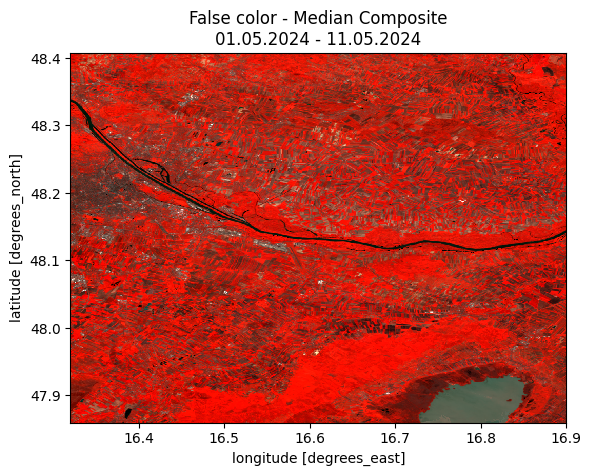

In [5]:
# compute a false color image
# near infrared instead of red
fc_median = (
    dc[["nir", "green", "blue"]]
    .where(dc.valid)
    .to_dataarray(dim="band")
    .transpose(..., "band")
    .median(dim="time")
    .astype(int)
)

title_fc = (
    "False color - Median Composite"
    + f"\n{start_date.strftime('%d.%m.%Y')} - {end_date.strftime('%d.%m.%Y')}"
)
fc_median.plot.imshow(robust=True).axes.set_title(title_fc)
plt.show()

### Part 2: Baseline -- NDVI + Otsu's Method

Using the appropriate Sentinel 2 bands, calculate and plot NDVI for the image. Apply Otsu's method to produce a binary vegetation mask. Recall that our task for this lab is to classify forest cover. Given the land cover in and around Vienna (take a look at your RGB image if you don't know what it looks like), why might NDVI + Otsu's rule not be appropriate here?

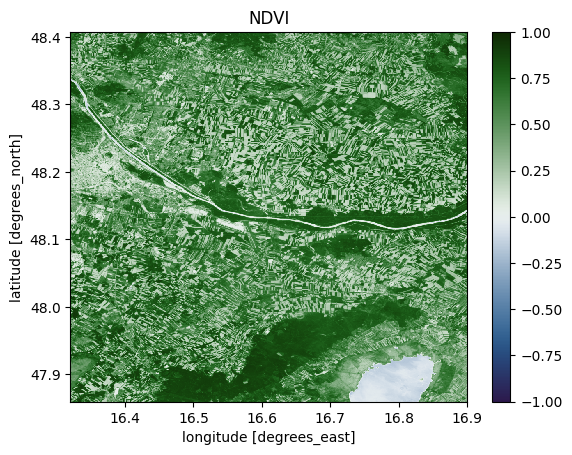

In [6]:
#NDVI
def normalized_difference(a, b):
    return (a-b*1.0) / (a+b)

ndvi = normalized_difference(dc.nir, dc.red)
ndvi.median(dim="time").plot.imshow(cmap="cmc.cork", vmin=-1, vmax=1).axes.set_title(
    "NDVI"
)
plt.show()

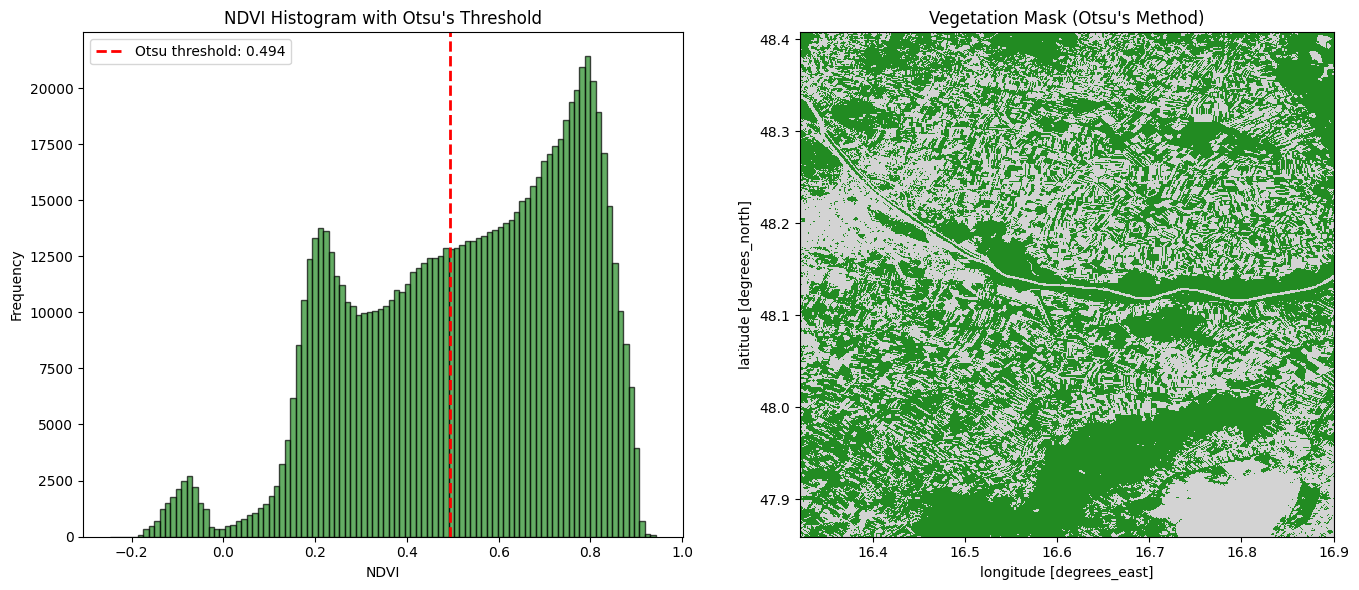

In [7]:
ndvi_median = ndvi.median(dim="time")

#Apply Otsu's method
ndvi_values = ndvi_median.values.flatten()
ndvi_valid = ndvi_values[~np.isnan(ndvi_values)]

otsu_threshold = threshold_otsu(ndvi_valid)

#create binary mask
vegetation_mask_otsu = ndvi_median > otsu_threshold

#plot results
fig4, axes4 = plt.subplots(1, 2, figsize=(14, 6))

#histogram with threshold
axes4[0].hist(ndvi_valid, bins=100, color="forestgreen", alpha=0.7, edgecolor="black")
axes4[0].axvline(
    otsu_threshold,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Otsu threshold: {otsu_threshold:.3f}",
)
axes4[0].set_xlabel("NDVI")
axes4[0].set_ylabel("Frequency")
axes4[0].set_title("NDVI Histogram with Otsu's Threshold")
axes4[0].legend()

# Binary mask
cmap_binary = mcolors.ListedColormap(["lightgray", "forestgreen"])
vegetation_mask_otsu.plot.imshow(ax=axes4[1], cmap=cmap_binary, add_colorbar=False)
axes4[1].set_title("Vegetation Mask (Otsu's Method)")
axes4[1].set_aspect("equal")

plt.tight_layout()

### Part 3: Classification

Plot the training samples provided by the Project Pythia cookbook, as they do. Examine the polygons. What do you notice about their size, placement, and composition? How might this impact the results of our model? (Hint: what land cover classes does each polygon actually include?)

In [8]:
#regions of interest
# Define Polygons
forest_areas = {
    0: [
        Polygon(
            [
                (16.482772, 47.901753),
                (16.465133, 47.870124),
                (16.510142, 47.874382),
                (16.482772, 47.901753),
            ]
        )
    ],
    1: [
        Polygon(
            [
                (16.594079, 47.938855),
                (16.581914, 47.894454),
                (16.620233, 47.910268),
                (16.594079, 47.938855),
            ]
        )
    ],
    2: [
        Polygon(
            [
                (16.67984, 47.978998),
                (16.637263, 47.971091),
                (16.660376, 47.929123),
                (16.67984, 47.978998),
            ]
        )
    ],
    3: [
        Polygon(
            [
                (16.756477, 48.000286),
                (16.723024, 47.983256),
                (16.739446, 47.972916),
                (16.756477, 48.000286),
            ]
        )
    ],
    4: [
        Polygon(
            [
                (16.80696, 48.135923),
                (16.780806, 48.125583),
                (16.798445, 48.115243),
                (16.80696, 48.135923),
            ]
        )
    ],
    5: [
        Polygon(
            [
                (16.684097, 48.144438),
                (16.664634, 48.124366),
                (16.690788, 48.118892),
                (16.684097, 48.144438),
            ]
        )
    ],
    6: [
        Polygon(
            [
                (16.550894, 48.169984),
                (16.530822, 48.165118),
                (16.558801, 48.137139),
                (16.550894, 48.169984),
            ]
        )
    ],
    7: [
        Polygon(
            [
                (16.588604, 48.402329),
                (16.556976, 48.401112),
                (16.580697, 48.382865),
                (16.588604, 48.402329),
            ]
        )
    ],
}

nonforest_areas = {
    0: [
        Polygon(
            [
                (16.674974, 48.269126),
                (16.623882, 48.236281),
                (16.682272, 48.213168),
                (16.674974, 48.269126),
            ]
        )
    ],
    1: [
        Polygon(
            [
                (16.375723, 48.228374),
                (16.357476, 48.188839),
                (16.399444, 48.185798),
                (16.375723, 48.228374),
            ]
        )
    ],
    2: [
        Polygon(
            [
                (16.457834, 48.26426),
                (16.418907, 48.267301),
                (16.440804, 48.23324),
                (16.457834, 48.26426),
            ]
        )
    ],
    3: [
        Polygon(
            [
                (16.519266, 48.101861),
                (16.470607, 48.100645),
                (16.500411, 48.07145),
                (16.519266, 48.101861),
            ]
        )
    ],
    4: [
        Polygon(
            [
                (16.453577, 48.051986),
                (16.412217, 48.067192),
                (16.425598, 48.012451),
                (16.453577, 48.051986),
            ]
        )
    ],
}

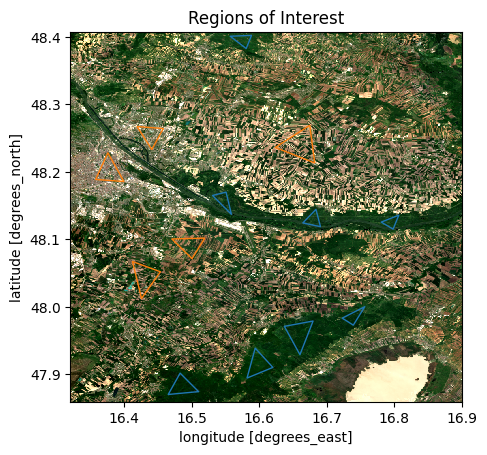

In [9]:
# Geoppandas Dataframe from Polygons
forest_df = gpd.GeoDataFrame(
    {"geometry": [poly[0] for poly in forest_areas.values()]}, crs="EPSG:4326"
)
nonforest_df = gpd.GeoDataFrame(
    {"geometry": [poly[0] for poly in nonforest_areas.values()]},
    crs="EPSG:4326",
)


# Plotting Regions of Interest
fig, ax = plt.subplots()
rgb_median.plot.imshow(ax=ax, robust=True)
forest_df.plot(ax=ax, ec="C0", fc="none")
nonforest_df.plot(ax=ax, ec="C1", fc="none")
ax.set_title("Regions of Interest")
ax.set_aspect("equal")
plt.show()

You'll be using the red, green, blue, and NIR bands for training and testing. Based on what you've learned in previous labs, why do you think we've selected these?

In [10]:
# Classifiying dataset (only necessary bands)
bands = ["red", "green", "blue", "nir"]
ds_class = dc[bands].where(dc.valid).median(dim="time")
ds_class = ds_class.fillna(0)


def clip_array(ds: xr.Dataset, polygons):
    clipped = ds.rio.clip(polygons, invert=False, all_touched=False, drop=True)
    clipped_nan = clipped.where(clipped == ds)
    return clipped_nan


# Dictionaries with Dataarrays, each clipped by a Polygon
data_dict_feat = {
    idx: clip_array(ds_class, polygon) for idx, polygon in forest_areas.items()
}
data_dict_nonfeat = {
    idx: clip_array(ds_class, polygon) for idx, polygon in nonforest_areas.items()
}

In [11]:
# Reshape the polygon dataarrays to get a tuple (one value per band) of pixel values
feat_data = [
    xarray.to_array().values.reshape(len(bands), -1).T
    for xarray in data_dict_feat.values()
]  # replaced median_data_dict_feat with data_dict_feat
nonfeat_data = [
    xarray.to_array().values.reshape(len(bands), -1).T
    for xarray in data_dict_nonfeat.values()
]  # replaced median_data_dict_feat with data_dict_feat

# The rows of the different polygons are concatenated to a single array for further processing
feat_values = np.concatenate(feat_data)
nonfeat_values = np.concatenate(nonfeat_data)

# Drop Nan Values
X_feat_data = feat_values[~np.isnan(feat_values).any(axis=1)]
X_nonfeat_data = nonfeat_values[~np.isnan(nonfeat_values).any(axis=1)]

Split your data into training and testing sets (use a 70/30 split here, not 50/50 as the Project Pythia notebook does). Standardize your input features as we did in the previous week's lab. Since we're going to be training a linear classifier in addition to the naive Bayes and Random Forest, we'll need to standardize (although we wouldn't have to do this if we were just making the naive Bayes and Random Forest).

In [12]:
# Creating Output Vector (1 for pixel is features; 0 for pixel is not feature)
y_feat_data = np.ones(X_feat_data.shape[0])
y_nonfeat_data = np.zeros(X_nonfeat_data.shape[0])

# Concatenate all Classes for training
X = np.concatenate([X_feat_data, X_nonfeat_data])
y = np.concatenate([y_feat_data, y_nonfeat_data])

# Split into Training and Testing Data.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.7, random_state=42
)

In [13]:
# Standardize features (required for linear classifier)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

NameError: name 'StandardScaler' is not defined

In [ ]:
# Prepare full image for prediction
image_data = (
    ds_class[bands].to_array(dim="band").transpose("latitude", "longitude", "band")
)

num_pixels = ds_class.sizes["longitude"] * ds_class.sizes["latitude"]
num_bands = len(bands)
X_image = image_data.values.reshape(num_pixels, num_bands)
X_image_scaled = scaler.transform(X_image)

img_shape = (ds_class.sizes["latitude"], ds_class.sizes["longitude"])



Train a linear classifier, naive Bayes, and Random Forest model. For each, examine the classification report, confusion matrix, and a map of the predictions.

Compare the results of each classifier. Which model is most accurate?

Map a 2x2 grid of the outputs of the threshold approach and all three classifiers. Following the Project Pythia cookbook, map a classification comparison of the threshold and each of the models (this should give you three such comparisons). Where does each model differ from the threshold? What types of pixels seem to generate disagreement?

Pick your most accurate model and add the NDVI as an additional feature. Retrain the model and test the model. Does performance improve? When you map the output, do you see any changes in the accuracy of the map, or in the areas that it classifies? Would you say that including NDVI as a feature improves performance?